# Movie Sentiment Analysis

Dataset link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [1]:
import pandas as pd

In [2]:
url_path = "data/IMDB Dataset.csv"
df_original = pd.read_csv(url_path)

In [3]:
df = df_original

In [4]:
df = df_original.copy(deep=True)

# Basic Info

In [5]:
print(df.columns.to_list())

['review', 'sentiment']


In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
50000 - 49582 # no of duplicate rows

418

In [11]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Descriptive Stats

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Summary Statistics
df['review_char_len'] = df['review'].apply(len)
df['review_word_len'] = df['review'].apply(lambda x: len(x.split()))

# Descriptive stats
print(df[['review_char_len','review_word_len']].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


In [ ]:
# does too short or too long reviews has any relation to sentiment

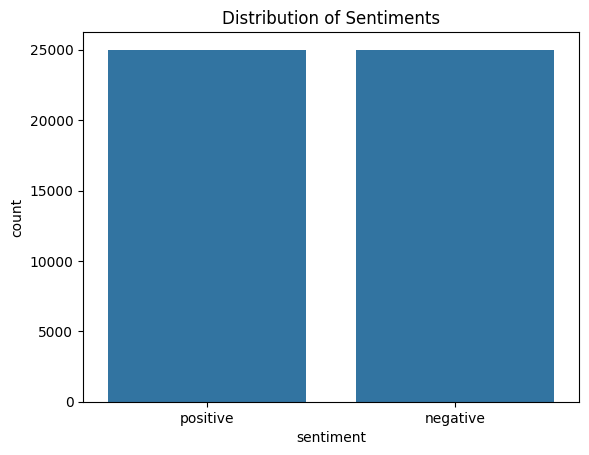

In [15]:
# Sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

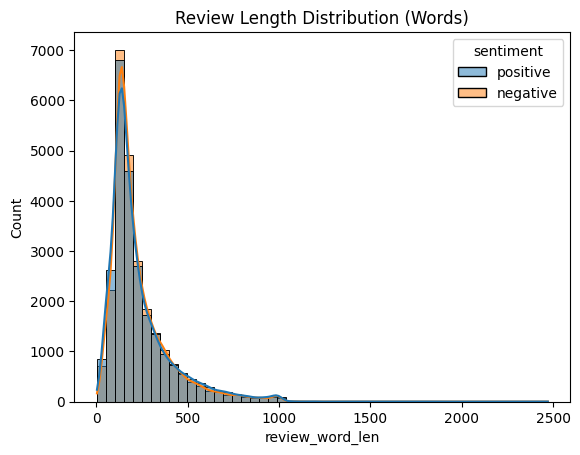

In [16]:
# Histogram of review word lengths
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

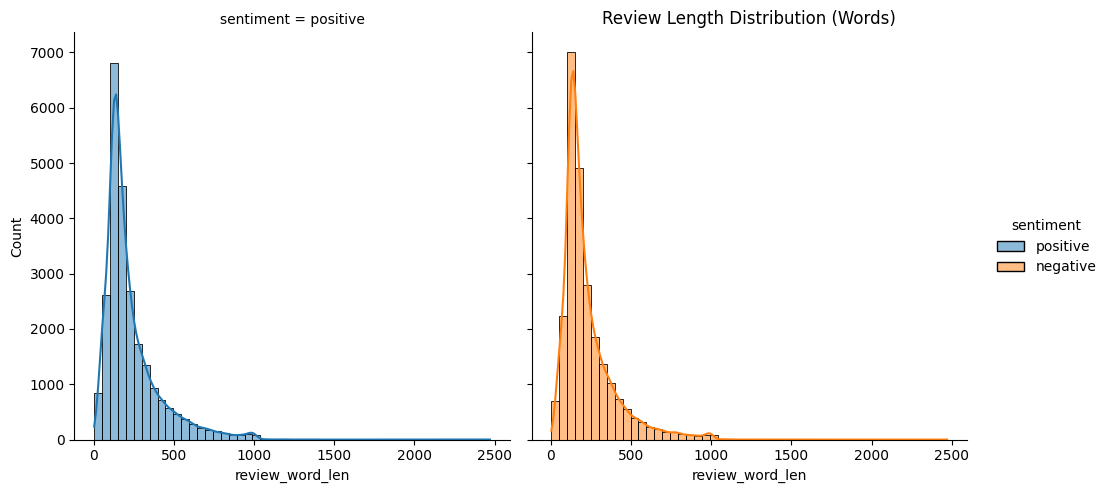

In [22]:
# Histogram of review word lengths
sns.displot(data=df, x='review_word_len', bins=50, col="sentiment", hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

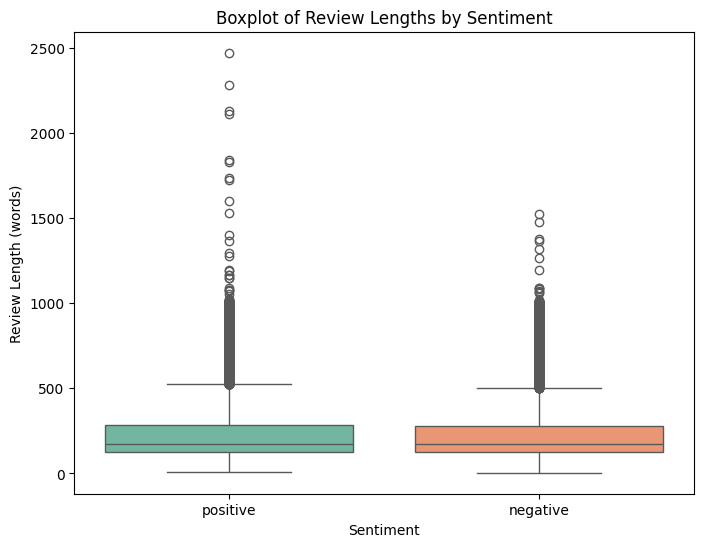

In [23]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

# Removing outliers

In [24]:
import numpy as np

In [26]:
# Calculate Q1, Q3, and IQR
Q1 = df['review_word_len'].quantile(0.25)
Q3 = df['review_word_len'].quantile(0.75)
IQR = Q3 - Q1

In [27]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -105.0
Upper Bound: 511.0


In [28]:
outliers = df[(df['review_word_len'] < lower_bound) | (df['review_word_len'] > upper_bound)]
# DF of outliers

In [29]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [30]:
50000-3708

46292

In [31]:
# FE STEP
df_clean_from_iqr = df[(df['review_word_len'] >= lower_bound) & (df['review_word_len'] <= upper_bound)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


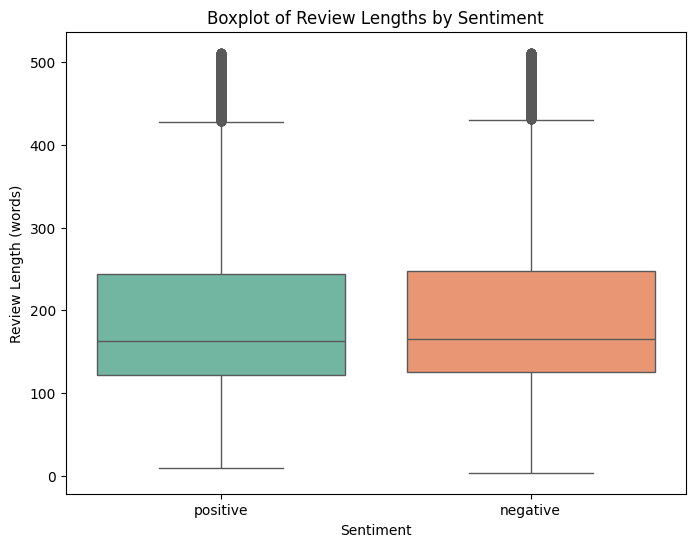

In [32]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [33]:
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [ ]:
# how many positive words in a positive case -->
# how many negative words in a negative case -->